# Concrete Compressive Strength — Round 2

Goal: lowest MSE on the 60-row holdout (`concrete_test2.csv`). The holdout has no labels, so every model is scored with
**repeated 10-fold cross-validation** (10 folds × 5 repeats = 50 train/test splits) on the 670 training rows.
All models use the *same* splits, so their MSEs are directly comparable.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
from lightgbm import LGBMRegressor

In [2]:
df_train = pd.read_csv('concrete_training.csv')
df_test = pd.read_csv('concrete_test2.csv')

PREDICTORS = ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer',
              'CoarseAggregate', 'FineAggregate', 'Age']
X = df_train[PREDICTORS]
y = df_train['Strength']
print(X.shape, df_test.shape)

(670, 8) (60, 9)


## Shared setup

**Feature functions**
- `log_age`: replaces Age with log(Age). Strength climbs fast in the first weeks and then levels off, which a log captures.
- `log_age_ratios`: also adds the water/cement ratio and water/binder ratio (binder = cement + slag + fly ash),
  the standard concrete-engineering predictors of strength.

**Scoring**: `cv_mse` runs the 50 splits and returns the mean test-fold MSE. Results are collected in `results`.

In [3]:
def log_age(df):
    df = df.copy()
    df['Age'] = np.log(df['Age'])
    return df

def log_age_ratios(df):
    df = log_age(df)
    df['WaterCement'] = df['Water'] / df['Cement']
    df['WaterBinder'] = df['Water'] / (df['Cement'] + df['BlastFurnaceSlag'] + df['FlyAsh'])
    return df

cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
results = {}

def cv_mse(name, model):
    scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    results[name] = scores
    print(f'{name}: CV MSE = {scores.mean():.2f}  (± {scores.std() / np.sqrt(len(scores)):.2f} s.e.)')
    return scores.mean()

def poly_model(features, degree, estimator):
    # features -> standardize -> polynomial expansion -> standardize again -> regression
    return make_pipeline(FunctionTransformer(features), StandardScaler(),
                         PolynomialFeatures(degree, include_bias=False), StandardScaler(), estimator)

## 1. Linear regression (Round 1 benchmark)

Ordinary least squares on the 8 predictors with log(Age). Each predictor gets one slope, so the model assumes every
extra kg of cement adds the same strength no matter the mix or age. This is the baseline to beat
(our Round 1 holdout MSE was ~55).

In [4]:
linear = make_pipeline(FunctionTransformer(log_age), LinearRegression())
cv_mse('1. Linear OLS', linear)

1. Linear OLS: CV MSE = 54.29  (± 1.37 s.e.)


np.float64(54.28721464394533)

## 2. Quadratic regression (squares + pairwise products)

Still OLS, but with 44 columns: the 8 predictors, their 8 squares (Cement², …) and all 28 pairwise products
(Cement×Age, Water×Superplasticizer, …). Squares let each effect curve; products let one variable's effect depend
on another (e.g. cement matters more as the concrete ages).

In [5]:
quad = poly_model(log_age, 2, LinearRegression())
cv_mse('2. Quadratic OLS', quad)

2. Quadratic OLS: CV MSE = 37.38  (± 1.09 s.e.)


np.float64(37.382121964469654)

## 3. Quadratic regression + mix ratios

Same as model 2, but water/cement and water/binder are added *before* the expansion, giving 10 base features → 65 columns.
This is close to the 64-predictor model that won Round 1.

In [6]:
quad_ratios = poly_model(log_age_ratios, 2, LinearRegression())
cv_mse('3. Quadratic OLS + ratios', quad_ratios)

3. Quadratic OLS + ratios: CV MSE = 34.80  (± 0.98 s.e.)


np.float64(34.797225117299924)

## 4. Cubic regression with ridge penalty

Expands to degree 3 (cubes and three-way products like Cement×Water×Age): 164 columns from 8 features. Plain OLS overfits
with this many columns, so **ridge** adds a penalty λ·Σβ² that shrinks all coefficients toward zero. `RidgeCV` picks λ by
internal cross-validation on each training fold, so the reported MSE stays honest.

In [7]:
ALPHAS = np.logspace(-3, 3, 50)
cubic_ridge = poly_model(log_age, 3, RidgeCV(alphas=ALPHAS))
cv_mse('4. Cubic ridge', cubic_ridge)

cubic_ridge_ratios = poly_model(log_age_ratios, 3, RidgeCV(alphas=ALPHAS))
cv_mse('4b. Cubic ridge + ratios', cubic_ridge_ratios)

4. Cubic ridge: CV MSE = 32.96  (± 1.16 s.e.)


4b. Cubic ridge + ratios: CV MSE = 30.39  (± 1.12 s.e.)


np.float64(30.39248157000874)

## 5. Cubic regression with lasso penalty

Same 164 cubic columns, but **lasso** penalizes λ·Σ|β|, which sets many coefficients exactly to zero. The result is
a model that automatically selects which terms matter. λ is again chosen by internal CV.

In [8]:
cubic_lasso = poly_model(log_age, 3, LassoCV(cv=5, max_iter=50000, random_state=0))
cv_mse('5. Cubic lasso', cubic_lasso)

cubic_lasso.fit(X, y)
coefs = cubic_lasso[-1].coef_
print(f'Lasso kept {np.sum(coefs != 0)} of {len(coefs)} terms')

5. Cubic lasso: CV MSE = 31.62  (± 1.08 s.e.)
Lasso kept 89 of 164 terms


## 6. Random forest

Averages 500 decision trees, each grown on a bootstrap sample of the rows and considering a random subset of features at
each split. Trees split the data into boxes and predict the box average, so they find nonlinearities and interactions
on their own with no feature expansion. They predict in steps, which can hurt when the true relationship is smooth.

In [9]:
rf = make_pipeline(FunctionTransformer(log_age_ratios),
                   RandomForestRegressor(n_estimators=500, min_samples_leaf=2, max_features=0.5,
                                         n_jobs=1, random_state=0))
cv_mse('6. Random forest', rf)

6. Random forest: CV MSE = 33.52  (± 1.23 s.e.)


np.float64(33.51938551793211)

## 7. Gradient boosting (LightGBM)

Builds small trees **one after another**, each fit to the errors the previous trees still make, and adds them up with a
small learning rate. This is usually the strongest off-the-shelf method for tabular data. Three settings are compared:
fewer larger trees vs. many small trees.

In [10]:
def lgbm(learning_rate, n_estimators, num_leaves):
    return make_pipeline(FunctionTransformer(log_age_ratios),
                         LGBMRegressor(learning_rate=learning_rate, n_estimators=n_estimators,
                                       num_leaves=num_leaves, min_child_samples=10,
                                       subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                       verbose=-1, n_jobs=1, random_state=0))

lgbm_settings = {'7a. LightGBM (lr .05, 400 trees, 15 leaves)': (0.05, 400, 15),
                 '7b. LightGBM (lr .02, 1500 trees, 4 leaves)': (0.02, 1500, 4),
                 '7c. LightGBM (lr .01, 3000 trees, 4 leaves)': (0.01, 3000, 4)}
lgbm_scores = {name: cv_mse(name, lgbm(*params)) for name, params in lgbm_settings.items()}
best_lgbm_name = min(lgbm_scores, key=lgbm_scores.get)
best_lgbm = lgbm(*lgbm_settings[best_lgbm_name])
print('Best LightGBM:', best_lgbm_name)

7a. LightGBM (lr .05, 400 trees, 15 leaves): CV MSE = 27.27  (± 1.30 s.e.)


7b. LightGBM (lr .02, 1500 trees, 4 leaves): CV MSE = 29.79  (± 1.18 s.e.)


7c. LightGBM (lr .01, 3000 trees, 4 leaves): CV MSE = 29.75  (± 1.19 s.e.)
Best LightGBM: 7a. LightGBM (lr .05, 400 trees, 15 leaves)


## 8. Ensemble (average of the best polynomial model and the best boosting model)

Averages the predictions of the best polynomial model and the best LightGBM. The two make different kinds of
errors (smooth curve vs. step function), so averaging them often cancels part of each one's error.

In [11]:
poly_candidates = {'4. Cubic ridge': cubic_ridge, '4b. Cubic ridge + ratios': cubic_ridge_ratios,
                   '5. Cubic lasso': cubic_lasso}
best_poly_name = min(poly_candidates, key=lambda n: results[n].mean())
print('Best polynomial model:', best_poly_name)

ensemble = VotingRegressor([('poly', poly_candidates[best_poly_name]), ('lgbm', best_lgbm)])
cv_mse('8. Ensemble (poly + LightGBM)', ensemble)

Best polynomial model: 4b. Cubic ridge + ratios


8. Ensemble (poly + LightGBM): CV MSE = 24.28  (± 1.10 s.e.)


np.float64(24.27995285884279)

## Comparison

                                             CV MSE  Std. error
8. Ensemble (poly + LightGBM)                 24.28        1.10
7a. LightGBM (lr .05, 400 trees, 15 leaves)   27.27        1.30
7c. LightGBM (lr .01, 3000 trees, 4 leaves)   29.75        1.19
7b. LightGBM (lr .02, 1500 trees, 4 leaves)   29.79        1.18
4b. Cubic ridge + ratios                      30.39        1.12
5. Cubic lasso                                31.62        1.08
4. Cubic ridge                                32.96        1.16
6. Random forest                              33.52        1.23
3. Quadratic OLS + ratios                     34.80        0.98
2. Quadratic OLS                              37.38        1.09
1. Linear OLS                                 54.29        1.37


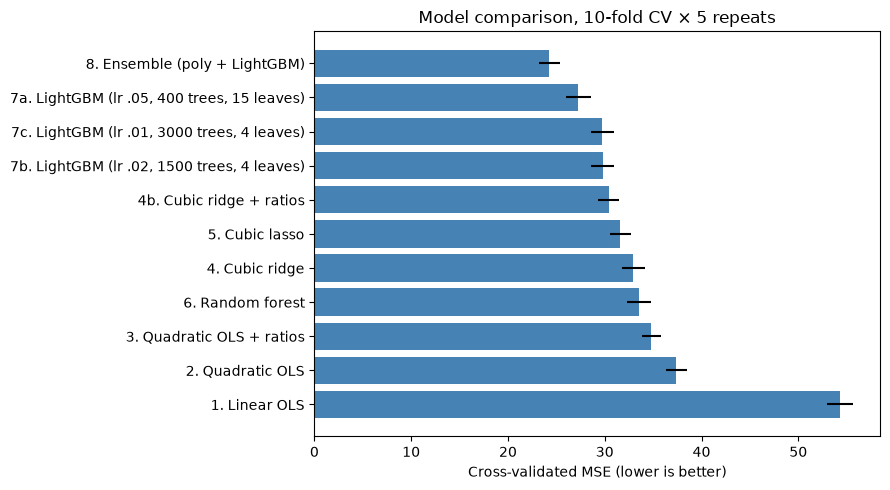

In [12]:
summary = pd.DataFrame({'CV MSE': {k: v.mean() for k, v in results.items()},
                        'Std. error': {k: v.std() / np.sqrt(len(v)) for k, v in results.items()}})
summary = summary.sort_values('CV MSE')
print(summary.round(2).to_string())

plt.figure(figsize=(9, 5))
plt.barh(summary.index[::-1], summary['CV MSE'][::-1], xerr=summary['Std. error'][::-1], color='steelblue')
plt.xlabel('Cross-validated MSE (lower is better)')
plt.title('Model comparison, 10-fold CV × 5 repeats')
plt.tight_layout()
plt.show()

## Final model and holdout predictions

The model with the lowest CV MSE is refit on all 670 training rows and used to predict the 60 holdout observations.

In [13]:
all_models = {'1. Linear OLS': linear, '2. Quadratic OLS': quad, '3. Quadratic OLS + ratios': quad_ratios,
              '4. Cubic ridge': cubic_ridge, '4b. Cubic ridge + ratios': cubic_ridge_ratios,
              '5. Cubic lasso': cubic_lasso, '6. Random forest': rf, best_lgbm_name: best_lgbm,
              '8. Ensemble (poly + LightGBM)': ensemble}
final_name = summary.index[0]
final_model = all_models[final_name].fit(X, y)
print('Final model:', final_name)

predictions = pd.DataFrame({'ID': df_test['ID'],
                            'PredictedStrength': final_model.predict(df_test[PREDICTORS]).round(2)})
predictions.to_csv('concrete_predictions2.csv', index=False)
print(predictions.to_string(index=False))

Final model: 8. Ensemble (poly + LightGBM)
 ID  PredictedStrength
  1              39.94
  2              64.50
  3              28.38
  4              25.71
  5              32.47
  6              52.58
  7              12.33
  8              35.23
  9              20.25
 10              53.88
 11              31.27
 12              42.63
 13              40.34
 14               9.20
 15              26.49
 16              40.16
 17              16.17
 18              16.77
 19              29.23
 20              17.03
 21              44.62
 22              51.88
 23              30.46
 24              73.82
 25              49.53
 26              39.17
 27              22.45
 28              39.63
 29              13.14
 30              25.23
 31              43.04
 32              46.71
 33              37.46
 34              18.94
 35               7.54
 36              18.49
 37              46.48
 38              39.02
 39              40.05
 40              67.09
 41           